In [1]:
pip install tiktoken

In [2]:
import os
import requests

if not os.path.exists("the-verdict.txt"):
  url = ("https://raw.githubusercontent.com/rasbt/"
  "LLMs-from-scratch/main/ch02/01_main-chapter-code/"
  "the-verdict.txt")
  file_path = "the-verdict.txt"
  response = requests.get(url)
  response.raise_for_status()
  with open(file_path, "wb") as f:
    f.write(response.content)
with open("the-verdict.txt", "r", encoding = "utf-8") as f:
  text_raw = f.read()
len_text_raw = len(text_raw)
print(len_text_raw)

text_raw[:10]

20479


'I HAD alwa'

In [3]:
import re
preprocessed = re.split(r'([,.:;?_!"()\']|--|\s)', text_raw)
preprocessed = [i.strip() for i in preprocessed if i.strip()]
preprocessed
len(preprocessed)
#Creating a Vocabulary with Tokens and Token IDs
total_words = sorted(set(preprocessed))
vocabulary = {token : index for index, token in enumerate(preprocessed)}
vocabulary
len(vocabulary)

1130

In [4]:
class TokenizerV1:
  def __init__(self, vocabulary):
    self.string_to_int = vocabulary
    self.int_to_string = {i:s for s,i in vocabulary.items()}

  def get_vocab(self):
    return self.int_to_string

  def encode(self, text):
    preprocessed = re.split(r'([,:;?_!"()\']|--|\s)', text)
    preprocessed = [i.strip() for i in preprocessed if i.strip()]
    preprocessed = [i if i in self.string_to_int else "<|unk|>" for i in preprocessed]
    ids = [self.string_to_int[s] for s in preprocessed]
    return ids

  def decode(self, ids):
    text = " ".join([self.int_to_string[i] for i in ids])
    text = re.sub(r'\s+([,.?!"()\'])', r'\1', text)
    return text

In [5]:
tokenizer = TokenizerV1(vocabulary)
text = "It's the last he painted, you know"
ids = tokenizer.encode(text)
ids
#tokenizer.get_vocab().keys()
tokenizer.decode(ids)

"It' s the last he painted, you know"

In [6]:
tokens = sorted(list(set(preprocessed)))
tokens.extend(["<|endoftext|>", "<|unk|>"])
vocabulary = {token: integer for integer, token in enumerate(tokens)}
vocabulary.items()
tokenizer1 = TokenizerV1(vocabulary)
txt = "do you like tea? <|endoftext|>"
tokenizer1.encode(txt)

[355, 1126, 628, 975, 10, 1130]

In [7]:
# Target vector is 1 shift of I/P vector

context_length = 4
encoded_txt = tokenizer1.encode(text_raw)
for i in range(1, context_length + 1):
  context_window =  encoded_txt[:i]
  target_to_be = encoded_txt[i]
  print(tokenizer1.decode(context_window), "->", tokenizer1.decode([target_to_be]))

I -> HAD
I HAD -> always
I HAD always -> thought
I HAD always thought -> Jack


In [8]:
import torch
from torch.utils.data import Dataset, DataLoader

In [9]:
class DatasetV1(Dataset):
  def __init__(self, text, tokenizer, max_length, stride):
    self.input_ids = []
    self.target_ids = []

    token_ids = tokenizer.encode(text, allowed_special={"<|endoftext|>"})
    assert len(token_ids) > max_length, "Number of tokenized inputs must at least be equal to max_length+1"

    for i in range(0, len(token_ids) - max_length, stride):
      input_chunk = token_ids[i : i + max_length]
      target_chunk = token_ids[i+1 : i + max_length + 1]
      self.input_ids.append(torch.tensor(input_chunk))
      self.target_ids.append(torch.tensor(target_chunk))

  def __len__(self):
    return len(self.input_ids)

  def __getitem__(self, index):
    return self.input_ids[index], self.target_ids[index]

In [10]:
import tiktoken

def create_DataLoaderV1(text, batch_size = 4, max_length = 256, stride = 128, shuffle = True, drop_last = True, num_workers = 0):
  tokenizer = tiktoken.get_encoding("gpt2")
  dataset = DatasetV1(text, tokenizer, max_length, stride)
  dataloader = DataLoader(dataset, batch_size = batch_size, shuffle = shuffle, drop_last = drop_last, num_workers = num_workers)
  return dataloader
dataloader = create_DataLoaderV1(text_raw, batch_size = 4, max_length = 7, stride = 1, shuffle = False)
print(next(iter(dataloader)))
# To avoid Overfitting, increase the stride!

dataloader1 = create_DataLoaderV1(text_raw, batch_size = 7, max_length = 4, stride = 4, shuffle = False )
print(next(iter(dataloader1)))

[tensor([[   40,   367,  2885,  1464,  1807,  3619,   402],
        [  367,  2885,  1464,  1807,  3619,   402,   271],
        [ 2885,  1464,  1807,  3619,   402,   271, 10899],
        [ 1464,  1807,  3619,   402,   271, 10899,  2138]]), tensor([[  367,  2885,  1464,  1807,  3619,   402,   271],
        [ 2885,  1464,  1807,  3619,   402,   271, 10899],
        [ 1464,  1807,  3619,   402,   271, 10899,  2138],
        [ 1807,  3619,   402,   271, 10899,  2138,   257]])]
[tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,   438,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502]]), tensor([[  367,  2885,  1464,  1807],
        [ 3619,   402,   271, 10899],
        [ 2138,   257,  7026, 15632],
        [  438,  2016,   257,   922],
        [ 5891,  1576,   438,   568],
        [  340,   373,   645,  1049],
        [ 5975,   284,   5

In [13]:
vocabulary_size = 50257
output_dim = 256
context_length = 1024

token_embedding_layer = torch.nn.Embedding(vocabulary_size, output_dim)
position_embedding_layer = torch.nn.Embedding(context_length, output_dim)

for batch in dataloader:
  x,y = batch
  token_embeddings = token_embedding_layer(x)
  position_embeddings = position_embedding_layer(torch.arange(7))
  input_embeddings = token_embeddings + position_embeddings
  break
input_embeddings.shape


torch.Size([4, 7, 256])

In [14]:
# Self- attention mechanism

inputs = torch.tensor(
    [
        [0.43, 0.15, 0.89],
        [0.55, 0.87, 0.66],
        [0.57, 0.85, 0.64],
        [0.22, 0.58, 0.33],
        [0.77, 0.25, 0.10],
        [0.05, 0.80, 0.55]
    ]
)

query = inputs[1]
attention_scores = torch.empty(inputs.shape[0])
attention_scores
for i, xi in enumerate(inputs):
  print(i, xi)
  attention_scores[i] = torch.dot(xi, query)
attention_scores
# Normalize the scores so that their sum is 1
attention_weights_normalized = attention_scores / attention_scores.sum()
attention_weights_normalized.sum()

0 tensor([0.4300, 0.1500, 0.8900])
1 tensor([0.5500, 0.8700, 0.6600])
2 tensor([0.5700, 0.8500, 0.6400])
3 tensor([0.2200, 0.5800, 0.3300])
4 tensor([0.7700, 0.2500, 0.1000])
5 tensor([0.0500, 0.8000, 0.5500])


tensor(1.0000)

In [15]:
def softmax(x):
  return torch.exp(x) / torch.exp(x).sum(dim = 0)

attention_weights_softmax_normalized = softmax(attention_scores)
attention_weights_softmax_normalized.sum()
# Computing the Context vector corresponding to the 2nd I/P token, as we considered it to be query

query = inputs[1]
context_vector_2 = torch.zeros(query.shape)
for i,xi in enumerate(inputs):
  context_vector_2 += attention_weights_softmax_normalized[i] * xi

context_vector_2


tensor([0.4419, 0.6515, 0.5683])

In [17]:
# Now, we'll compute the Attention Weights for all Input Tokens

attention_scores_all_tokens = torch.empty(6,6)

for i,xi in enumerate(inputs):
  for j,xj in enumerate(inputs):
    attention_scores_all_tokens [i,j] = torch.dot(xi, xj)

attention_scores_all_tokens
# Alternative
attention_scores_all_tokens = inputs @ inputs.T
attention_scores_all_tokens
attention_weights_all_tokens_softmax_normalized = torch.softmax(attention_scores_all_tokens, dim = 1)
attention_weights_all_tokens_softmax_normalized.sum(dim = -1)
# Context Vectors

context_vectors_all_tokens = attention_weights_all_tokens_softmax_normalized @ inputs
context_vectors_all_tokens
# Calculating Attention Weights via steps!

# SCALED DOT-PRODUCT ATTENTION
'''
There are 3 matrices.. Query, Key, Vector
Used to project the embedded input tokens x(i) to q, k, v vectors via matrix multiplication
Query vector q(i) = x(i) Wq
Key vector k(i) = x(i) Wk
Value vector v(i) = x(i) Wv
'''

x2 = inputs[1]
din = inputs.shape[1] # I/P embedding size = 3
dout = 2 # O/P embedding size

# Randomize the Weight matrices' values.
W_query = torch.nn.Parameter(torch.rand(din, dout), requires_grad = False)
W_key = torch.nn.Parameter(torch.rand(din, dout), requires_grad = False)
W_value = torch.nn.Parameter(torch.rand(din, dout), requires_grad = False)

# Form the corresponding Vectors

query2 = x2 @ W_query
key2 = x2 @ W_key
value2 = x2 @ W_value

query2
keys = inputs @ W_key
values = inputs @ W_value
keys
# Attention Scores as Dot product btw query and each of the key vectors

key2 = keys[1]
attention_score_2_with_2 = query2.dot(key2)

# Attention score for query 2 with respect to all the keys (all tokens)

attention_score_2_with_all_tokens = query2 @ keys.T
attention_score_2_with_all_tokens
# We'll scale the attention score to get the attention  weight. Divide the scores by sq. root od dimension of embedding. Done to avoid vanishing gradients problem

dk = keys.shape[1]
attention_weight_2_with_all_tokens = torch.softmax(attention_score_2_with_all_tokens / dk ** 0.5, dim = -1)

attention_weight_2_with_all_tokens
# Context vector for the query2 with respect to all the values of all tokens

context_vector_2_with_all_tokens = attention_weight_2_with_all_tokens @ values
context_vector_2_with_all_tokens


tensor([1.0650, 0.7160])

In [18]:
# Creation of a class to perform the aforementioned fragments

import torch.nn as nn

class SelfAttentionMechanismV1(nn.Module):

  def __init__(self, din, dout):
    super().__init__()
    self.Wquery = nn.Parameter(torch.rand(din,dout))
    self.Wkey = nn.Parameter(torch.rand(din, dout))
    self.Wvalue = nn.Parameter(torch.rand(din, dout))

  def forward(self, x):
    keys = x @ self.Wkey
    queries = x @ self.Wquery
    values = x @ self.Wvalue

    attentionscores = queries @ keys.T
    attentionweights = torch.softmax(attentionscores / keys.shape[-1] ** 0.5, dim = -1)
    contextvector = attentionweights @ values
    return contextvector


In [19]:
inputs
torch.manual_seed(123)
selfattentionv1 = SelfAttentionMechanismV1(din, dout)
print(selfattentionv1(inputs))
# Using Linear layer since it has a weight initialization scheme


tensor([[0.2996, 0.8053],
        [0.3061, 0.8210],
        [0.3058, 0.8203],
        [0.2948, 0.7939],
        [0.2927, 0.7891],
        [0.2990, 0.8040]], grad_fn=<MmBackward0>)


In [20]:
class SelfAttentionMechanismV2(nn.Module):
  def __init__(self, din, dout, qkv_bias = False):
    super().__init__()
    self.Wquery = nn.Linear(din, dout, bias = qkv_bias)
    self.Wkey = nn.Linear(din, dout, bias = qkv_bias)
    self.Wvalue = nn.Linear(din, dout, bias = qkv_bias)

  def forward(self, x):
    keys = self.Wkey(x)
    queries = self.Wquery(x)
    values = self.Wvalue(x)
    attentionscores = queries @ keys.T
    attentionweights = torch.softmax(attentionscores / keys.shape[-1] ** 0.5, dim = -1)
    contextvector = attentionweights @ values
    return contextvector


In [21]:
torch.manual_seed(123)
selfattentionv2 = SelfAttentionMechanismV2(din, dout)
selfattentionv2(inputs)

tensor([[-0.5337, -0.1051],
        [-0.5323, -0.1080],
        [-0.5323, -0.1079],
        [-0.5297, -0.1076],
        [-0.5311, -0.1066],
        [-0.5299, -0.1081]], grad_fn=<MmBackward0>)

In [22]:
# Causal Attention implementation is done in order to hide to the LLM, the words that are likely to be appearing in the future.
# Here, upper triangle elements are masked.

queries = selfattentionv2.Wquery(inputs)
keys = selfattentionv2.Wkey(inputs)
attentionscores = queries @ keys.T
attentionweights = torch.softmax(attentionscores / keys.shape[-1] ** 0.5, dim = -1)
attentionweights
# We'll do the masking of the upper triangle elements
# PyTorch's tril() is used to keep all upper triangle elems as 0 and all lower triangle elements as 1
contextlength = attentionscores.shape[0]
simplemask = torch.tril(torch.ones(contextlength, contextlength))
simplemask
maskedattentionweights = attentionweights * simplemask
maskedattentionweights
# We'll re-normalize the values in order to get sum of each row as 1, since we'll apply softmax function

rowsums = maskedattentionweights.sum(dim = -1, keepdim = True)
normalizedandmaskedattentionweights = maskedattentionweights / rowsums
normalizedandmaskedattentionweights
# We can make upper triangle elements to be - infinity, since, if we apply softmax funciton, we have exp(-infinity) which is obviously 0!

masktobeapplied = torch.triu(torch.ones(contextlength, contextlength), diagonal = 1)
maskedattentionscores = attentionscores.masked_fill(masktobeapplied.bool(), -torch.inf)
maskedattentionweightsinfinity = torch.softmax(maskedattentionscores / keys.shape[-1] ** 0.5, dim = -1)
maskedattentionweightsinfinity
# We'll apply Droput layers to improve performance of the underlying nerual network
# We apply the Dropout to the step after computing the attention weights
# We use Droput rate = 50% (0.5)
# The non-dropped values will be scaled automatically to 1/0.5 = 2
# Scaling = 1 / (1 - droput_rate)

torch.manual_seed(123)
dropoutlayer = torch.nn.Dropout(0.5)
sample = torch.ones(6,6)
dropoutlayer(sample)
torch.manual_seed(123) # To rertain the randomly generated values during all executions
dropoutlayer(maskedattentionweightsinfinity)
# We support more no. of inputs via batching
batches = torch.stack((inputs, inputs), dim = 0)
batches.shape


torch.Size([2, 6, 3])

In [23]:
class CasualAttentionMechanism(nn.Module):

  def __init__(self, din, dout, contextlength, dropout, qkv_bias = False):
    super().__init__()
    self.dout = dout
    self.Wquery = nn.Linear(din, dout, bias = qkv_bias)
    self.Wkey = nn.Linear(din, dout, bias = qkv_bias)
    self.Wvalue = nn.Linear(din, dout, bias = qkv_bias)
    self.dropout = nn.Dropout(dropout)
    self.register_buffer('mask', torch.triu(torch.ones(contextlength, contextlength), diagonal = 1))


  def forward(self, x):
    batchdim, numtokens, din = x.shape
    print(batchdim, numtokens, din)
    keys = self.Wkey(x)
    queries = self.Wquery(x)
    values = self.Wvalue(x)
    attentionscores = queries @ keys.transpose(1, 2)
    attentionscores.masked_fill(self.mask.bool()[:numtokens, :numtokens], -torch.inf)
    attentionweights = torch.softmax(attentionscores / keys.shape[-1] ** 0.5, dim = -1)
    attentionweights = self.dropout(attentionweights)
    contextvector = attentionweights @ values
    return contextvector

In [24]:
torch.manual_seed(123)
contextlength = batches.shape[1]
casualattention = CasualAttentionMechanism(din, dout, contextlength, 0)
contextvector = casualattention(batches)
contextvector.shape
contextvector

2 6 3


tensor([[[-0.5337, -0.1051],
         [-0.5323, -0.1080],
         [-0.5323, -0.1079],
         [-0.5297, -0.1076],
         [-0.5311, -0.1066],
         [-0.5299, -0.1081]],

        [[-0.5337, -0.1051],
         [-0.5323, -0.1080],
         [-0.5323, -0.1079],
         [-0.5297, -0.1076],
         [-0.5311, -0.1066],
         [-0.5299, -0.1081]]], grad_fn=<UnsafeViewBackward0>)

In [25]:
# Multi-Head Attention Mechanism

class MultiHeadAttentionMechanismWrapper(nn.Module):

  def __init__(self, din, dout, contextlength, dropout, numheads, qkvbias = False):
    super().__init__()
    self.heads = nn.ModuleList([CasualAttentionMechanism(din, dout, contextlength, dropout, qkvbias)
                               for _ in range(numheads)])

  def forward(self, x):
    return torch.cat([head(x) for head in self.heads], dim = -1)


In [26]:
torch.manual_seed(123)
contextlength =  batches.shape[1]
din, dout = 3, 2
multiheadattentionmechanism = MultiHeadAttentionMechanismWrapper(din, dout, contextlength, 0, numheads = 2)
contextvector = multiheadattentionmechanism(batches)
contextvector

2 6 3
2 6 3


tensor([[[-0.5337, -0.1051,  0.5085,  0.3508],
         [-0.5323, -0.1080,  0.5084,  0.3508],
         [-0.5323, -0.1079,  0.5084,  0.3506],
         [-0.5297, -0.1076,  0.5074,  0.3471],
         [-0.5311, -0.1066,  0.5076,  0.3446],
         [-0.5299, -0.1081,  0.5077,  0.3493]],

        [[-0.5337, -0.1051,  0.5085,  0.3508],
         [-0.5323, -0.1080,  0.5084,  0.3508],
         [-0.5323, -0.1079,  0.5084,  0.3506],
         [-0.5297, -0.1076,  0.5074,  0.3471],
         [-0.5311, -0.1066,  0.5076,  0.3446],
         [-0.5299, -0.1081,  0.5077,  0.3493]]], grad_fn=<CatBackward0>)

In [27]:
# Instead of concatenating several CasualAttentionMechanisms, we can create a standalone MultiHeadAttentionMechanism

class MultiHeadAttentionMechanismWrapperStandalone(nn.Module):
  def __init__(self, din, dout, contextlength, dropout, numheads, qkvbias = False):
    super().__init__()
    assert (dout % numheads == 0), "dout must be divisible by numheads"
    self.dout = dout
    self.numheads = numheads
    self.headdimension = dout // numheads # Desired O/P dimsn
    self.Wquery = nn.Linear(din, dout, bias = qkvbias)
    self.Wkey = nn.Linear(din, dout, bias = qkvbias)
    self.Wvalue = nn.Linear(din, dout, bias = qkvbias)
    self.opproj = nn.Linear(dout, dout) # Combine heads' O/Ps
    self.dropout = nn.Dropout(dropout)
    self.register_buffer("mask", torch.triu(torch.ones(contextlength, contextlength), diagonal = 1))

  def forward(self, x):
    b, numtokens, din = x.shape
    keys = self.Wkey(x)
    queries = self.Wquery(x)
    values = self.Wvalue(x)
    keys = keys.view(b, numtokens, self.numheads, self.headdimension)
    values = values.view(b, numtokens, self.numheads, self.headdimension)
    queries = queries.view(b, numtokens, self.numheads, self.headdimension)
    keys = keys.transpose(1, 2)
    queries = queries.transpose(1, 2)
    values = values.transpose(1, 2)

    attentionscores = queries @ keys.transpose(2, 3)
    maskasbool = self.mask.bool()[:numtokens, :numtokens]
    attentionscores.masked_fill_(maskasbool, -torch.inf)
    attentionweights = torch.softmax(attentionscores / keys.shape[-1] ** 0.5, dim = -1)
    attentionweights = self.dropout(attentionweights)

    contextvector = (attentionweights @ values).transpose(1, 2)
    contextvector = contextvector.contiguous().view(b, numtokens, self.dout)
    contextvector = self.opproj(contextvector)
    return contextvector


In [28]:
# Testing the standalone MultiHeadMechanism

torch.manual_seed(123)
batchsize, contextlength, din = batches.shape
dout = 2
multiheadattentionmechanismstandalone = MultiHeadAttentionMechanismWrapperStandalone(din, dout, contextlength, 0, numheads = 2)
contextvector = multiheadattentionmechanismstandalone(batches)
contextvector

tensor([[[0.3190, 0.4858],
         [0.2943, 0.3897],
         [0.2856, 0.3593],
         [0.2693, 0.3873],
         [0.2639, 0.3928],
         [0.2575, 0.4028]],

        [[0.3190, 0.4858],
         [0.2943, 0.3897],
         [0.2856, 0.3593],
         [0.2693, 0.3873],
         [0.2639, 0.3928],
         [0.2575, 0.4028]]], grad_fn=<ViewBackward0>)

In [29]:
class MultiHeadAttentionMechanismWrapperStandalone(nn.Module):
  def __init__(self, din, dout, contextlength, dropout, numheads, qkvbias = False):
    super().__init__()
    assert (dout % numheads == 0), "dout must be divisible by numheads"
    self.dout = dout
    self.numheads = numheads
    self.headdimension = dout // numheads # Desired O/P dimsn
    self.Wquery = nn.Linear(din, dout, bias = qkvbias)
    self.Wkey = nn.Linear(din, dout, bias = qkvbias)
    self.Wvalue = nn.Linear(din, dout, bias = qkvbias)
    self.opproj = nn.Linear(dout, dout) # Combine heads' O/Ps
    self.dropout = nn.Dropout(dropout)
    self.register_buffer("mask", torch.triu(torch.ones(contextlength, contextlength), diagonal = 1))

  def forward(self, x):
    b, numtokens, din = x.shape
    keys = self.Wkey(x)
    queries = self.Wquery(x)
    values = self.Wvalue(x)
    keys = keys.view(b, numtokens, self.numheads, self.headdimension)
    values = values.view(b, numtokens, self.numheads, self.headdimension)
    queries = queries.view(b, numtokens, self.numheads, self.headdimension)
    keys = keys.transpose(1, 2)
    queries = queries.transpose(1, 2)
    values = values.transpose(1, 2)

    attentionscores = queries @ keys.transpose(2, 3)
    maskasbool = self.mask.bool()[:numtokens, :numtokens]
    attentionscores.masked_fill_(maskasbool, -torch.inf)
    attentionweights = torch.softmax(attentionscores / keys.shape[-1] ** 0.5, dim = -1)
    attentionweights = self.dropout(attentionweights)

    contextvector = (attentionweights @ values).transpose(1, 2)
    contextvector = contextvector.contiguous().view(b, numtokens, self.dout)
    contextvector = self.opproj(contextvector)
    return contextvector

In [30]:
# Building an LLM Architecture

Configuration_for_GPT_Model_124MParams = {
    "vocabularysize" : 50257,
    "contextlength" : 1024,
    "embeddingdimension" : 768,
    "numberofheads" : 12, # no. of transformer blocks
    "numberoflayers" : 12,
    "dropoutrate" : 0.1,
    "qkvbias" : False
}

In [31]:
class ExampleGPTModel(nn.Module):
  def __init__(self, configuration):
    super().__init__()
    self.tokenembedding = nn.Embedding(configuration["vocabularysize"], configuration["embeddingdimension"])
    self.positionembedding = nn.Embedding(configuration["contextlength"], configuration["embeddingdimension"])
    self.dropoutembedding = nn.Dropout(configuration["dropoutrate"])

    self.transformerblocks = nn.Sequential(*[ExampleTransformerBlock(configuration) for _ in range(configuration["numberoflayers"])])
    self.finalnormalization = ExampleLayerNormalization(configuration["embeddingdimension"])
    self.outputhead = nn.Linear(configuration["embeddingdimension"], configuration["vocabularysize"], bias = False)

  def forward(self, idx):
    print(type(idx))
    batchsize, sequencelength = idx.shape
    tokenembeddings = self.tokenembedding(idx)
    positionembeddings = self.positionembedding(torch.arange(sequencelength, device = idx.device))
    x = tokenembeddings + positionembeddings
    x = self.dropoutembedding(x)
    x = self.transformerblocks(x)
    x = self.finalnormalization(x)
    logits = self.outputhead(x)
    return logits

In [32]:
class ExampleTransformerBlock(nn.Module):
  def __init__(self, configuration):
    super().__init__()

  def forward(self, x):
    return x

In [33]:
class ExampleLayerNormalization(nn.Module):
  def __init__(self, normalizedshape, epsilon = 1e-5):
    super().__init__()

  def forward(self, x):
    return x

In [34]:
tokenizer1 = tiktoken.get_encoding("gpt2")
#tokenizer2 = TokenizerV1(vocabulary)
batches1 = []
text1 = "Every effort moves you"
text2 = "Every day holds a"
batches1.append(torch.tensor(tokenizer1.encode(text1)))
batches1.append(torch.tensor(tokenizer1.encode(text2)))
batches1 = torch.stack(batches1, dim = 0)
batches1


tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])

In [35]:
torch.manual_seed(123)
gptmodel = ExampleGPTModel(Configuration_for_GPT_Model_124MParams)
logits = gptmodel(batches1)
print(logits)
logits.shape

<class 'torch.Tensor'>
tensor([[[-1.2034,  0.3201, -0.7130,  ..., -1.5548, -0.2390, -0.4667],
         [-0.1192,  0.4539, -0.4432,  ...,  0.2392,  1.3469,  1.2430],
         [ 0.5307,  1.6720, -0.4695,  ...,  1.1966,  0.0111,  0.5835],
         [ 0.0139,  1.6755, -0.3388,  ...,  1.1586, -0.0435, -1.0400]],

        [[-1.0908,  0.1798, -0.9484,  ..., -1.6047,  0.2439, -0.4530],
         [-0.7860,  0.5581, -0.0610,  ...,  0.4835, -0.0077,  1.6621],
         [ 0.3567,  1.2698, -0.6398,  ..., -0.0162, -0.1296,  0.3717],
         [-0.2407, -0.7349, -0.5102,  ...,  2.0057, -0.3694,  0.1814]]],
       grad_fn=<UnsafeViewBackward0>)


torch.Size([2, 4, 50257])

In [36]:
# Normalization of Activations using Layer Normalization
# Mean = 0 and Variance = 1
# Layer Normalization happens before and after multi-head attention module and also before the final output layer

# Example scenario
torch.manual_seed(123)
batchex = torch.randn(2,5)
layerex = nn.Sequential(nn.Linear(5,6), nn.ReLU())
outputex = layerex(batchex)
outputex
meanex = outputex.mean(dim = -1, keepdim = True)
varex = outputex.var(dim = -1, keepdim = True)
print("mean", meanex)
print("variance", varex)

mean tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)
variance tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>)


In [37]:
# Normalizing Formula Z = (x - mean) / std dev
# Z = (x - mean) / sqrt(var)

outputnormex = (outputex - meanex) / torch.sqrt(varex)
print(outputnormex.mean(dim = -1, keepdim = True))
print(outputnormex.var(dim = -1, keepdim = True))


tensor([[9.9341e-09],
        [1.9868e-08]], grad_fn=<MeanBackward1>)
tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


In [38]:
# We'll implement the same as the layer normalization for with z-score normalization for unit variance and 0 mean

class ExampleLayerNormalization(nn.Module):
  def __init__(self, embeddingdimension):
    super().__init__()
    self.epsilon = 1e-5
    self.scale = nn.Parameter(torch.ones(embeddingdimension))
    self.shift = nn.Parameter(torch.zeros(embeddingdimension))

  def forward(self, x):
    mean = x.mean(dim = -1, keepdim = True)
    variance = x.var(dim = -1, keepdim = True, unbiased = False)
    normalizedx = (x - mean) / torch.sqrt(variance + self.epsilon)
    return self.scale * normalizedx + self.shift

In [39]:
layernormalization = ExampleLayerNormalization(embeddingdimension= 6)
outln = layernormalization(outputex)
outln.var(dim = -1, keepdim = True, unbiased = False)
outln.mean(dim = -1, keepdim = True)

tensor([[ 0.0000e+00],
        [-1.9868e-08]], grad_fn=<MeanBackward1>)

In [40]:
# Introducing Feed Forward Network with GELU Activation function

class GeluActivationFunction(nn.Module):
  def __init__(self):
    super().__init__()

  def forward(self, x):
    return 0.5 * x * (1 + torch.tanh(torch.sqrt(torch.tensor(2.0 / torch.pi)) * (x + 0.044715 * torch.pow(x, 3))))

In [41]:
class FeedForward(nn.Module):
  def __init__(self, config):
    super().__init__()
    self.layers = nn.Sequential(nn.Linear(config["embeddingdimension"], 4 * config["embeddingdimension"]), nn.GELU(), nn.Linear(4 * config["embeddingdimension"], config["embeddingdimension"]))

  def forward(self, x):
    return self.layers(x)

In [42]:
feedforward = FeedForward(Configuration_for_GPT_Model_124MParams)
x = torch.rand(2, 3, 768)
outputsample = feedforward(x)
outputsample.shape

torch.Size([2, 3, 768])

In [43]:
# We'll add few Shortcut Connections to the feed forward netowrk to eradicate the vanishing gradient issues

class DeepNeuralNetwork(nn.Module):
  def __init__(self, layersizes, useshortcut):
    super().__init__()
    self.useshortcut = useshortcut
    self.layers = nn.ModuleList([
        nn.Sequential(nn.Linear(layersizes[0], layersizes[1]), GeluActivationFunction()),

                nn.Sequential(nn.Linear(layersizes[1], layersizes[2]), GeluActivationFunction()),

                nn.Sequential(nn.Linear(layersizes[2], layersizes[3]), GeluActivationFunction()),

                nn.Sequential(nn.Linear(layersizes[3], layersizes[4]), GeluActivationFunction()),

                nn.Sequential(nn.Linear(layersizes[0], layersizes[5]), GeluActivationFunction()),

    ])

  def forward(self, x):
    for layer in self.layers:
      layeroutput = layer(x)
      if self.useshortcut and x.shape == layeroutput.shape:
        x = x + layeroutput
      else:
        x = layeroutput
    return x

In [44]:
# Calculating the Gradients

def gradients(model, x):
  output = model(x)
  target = torch.tensor([[0.]])
  loss = nn.MSELoss()
  loss = loss(output, target)
  loss.backward()

  for name, parameter in model.named_parameters():
    if 'weight' in name:
      print(f"{name} has gradient mean of {parameter.grad.abs().mean().item()}")


In [45]:
layersizes = [3, 3, 3, 3, 3, 1]
sampleinput = torch.tensor([[1., 0., -1.]])
torch.manual_seed(123)
modelnoshortcut = DeepNeuralNetwork(layersizes, useshortcut = False)
gradients(modelnoshortcut, sampleinput)

layers.0.0.weight has gradient mean of 0.00020173584925942123
layers.1.0.weight has gradient mean of 0.00012011159560643137
layers.2.0.weight has gradient mean of 0.0007152040489017963
layers.3.0.weight has gradient mean of 0.0013988736318424344
layers.4.0.weight has gradient mean of 0.005049645435065031


In [46]:
# With Shortcut

torch.manual_seed(123)

modelyesshortcut = DeepNeuralNetwork(layersizes, useshortcut = True)
gradients(modelyesshortcut, sampleinput)

layers.0.0.weight has gradient mean of 0.22169791162014008
layers.1.0.weight has gradient mean of 0.20694105327129364
layers.2.0.weight has gradient mean of 0.32896995544433594
layers.3.0.weight has gradient mean of 0.2665732204914093
layers.4.0.weight has gradient mean of 1.3258540630340576


In [47]:
# We have to connect the Attention layer and Linear layers in transformer block

class ExampleTransformerBlock(nn.Module):
  def __init__(self, config):
    super().__init__()
    self.attentionlayer = MultiHeadAttentionMechanismWrapperStandalone(
        din = config["embeddingdimension"],
        dout = config["embeddingdimension"],
        contextlength = config["contextlength"],
        numheads = config["numberofheads"],
        dropout = config["dropoutrate"],
        qkvbias = config["qkvbias"]
    )

    self.feedforwardlayer = FeedForward(config)
    self.normalizationlayer1 = ExampleLayerNormalization(config["embeddingdimension"])
    self.normalizationlayer2 = ExampleLayerNormalization(config["embeddingdimension"])
    self.dropoutshortcut = nn.Dropout(config["dropoutrate"])


  def forward(self, x):
    shortcut = x
    x = self.normalizationlayer1(x)
    x = self.attentionlayer(x)
    x = self.dropoutshortcut(x)
    x = x + shortcut

    shortcut = x
    x = self.normalizationlayer2(x)
    x = self.feedforwardlayer(x)
    x = self.dropoutshortcut(x)
    x = x + shortcut

    return x

In [48]:
torch.manual_seed(123)
x = torch.rand(2, 4, 768)
block = ExampleTransformerBlock(Configuration_for_GPT_Model_124MParams)
op = block(x)
op

tensor([[[-0.0056,  0.0971, -0.1123,  ...,  1.2889,  0.2623,  0.6686],
         [ 0.0023, -0.2369,  0.1719,  ...,  0.5952,  0.2497,  0.7447],
         [ 0.4673,  0.4472,  0.1791,  ...,  1.2526,  0.3045,  0.7750],
         [ 0.0662,  0.7224,  0.9206,  ...,  0.4790,  0.7427,  0.7016]],

        [[ 0.3622,  1.2144,  0.5221,  ...,  0.1853,  0.0112, -0.5035],
         [-0.0225,  0.7790,  0.2769,  ...,  0.1734,  0.5419,  0.1143],
         [ 0.7425,  0.4013,  0.3210,  ...,  0.3268,  0.7523, -0.1642],
         [ 0.5745,  0.6241,  0.4410,  ...,  1.1963,  1.2649,  0.2243]]],
       grad_fn=<AddBackward0>)

In [49]:
# Final GPT Model
import torch.nn as nn

class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        print(cfg)
        self.tok_emb = nn.Embedding(cfg["vocabularysize"], cfg["embeddingdimension"])
        self.pos_emb = nn.Embedding(cfg["contextlength"], cfg["embeddingdimension"])
        self.drop_emb = nn.Dropout(cfg["dropoutrate"])

        self.trf_blocks = nn.Sequential(
            *[ExampleTransformerBlock(cfg) for _ in range(cfg["numberoflayers"])])

        self.final_norm = ExampleLayerNormalization(cfg["embeddingdimension"])
        self.out_head = nn.Linear(
            cfg["embeddingdimension"], cfg["vocabularysize"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds  # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

In [50]:
torch.manual_seed(123)
model = GPTModel(Configuration_for_GPT_Model_124MParams)

out = model(batches1)
out

{'vocabularysize': 50257, 'contextlength': 1024, 'embeddingdimension': 768, 'numberofheads': 12, 'numberoflayers': 12, 'dropoutrate': 0.1, 'qkvbias': False}


tensor([[[ 0.3612,  0.4223, -0.0712,  ...,  0.3483,  0.4661, -0.2838],
         [-0.1793, -0.5660, -0.9486,  ...,  0.0477,  0.5181, -0.3169],
         [ 0.7120,  0.0332,  0.1085,  ...,  0.1017, -0.4326, -0.2553],
         [-1.0076,  0.3419, -0.1190,  ...,  0.7195,  0.4023,  0.0532]],

        [[-0.2565,  0.0901,  0.0335,  ...,  0.2658,  0.4454, -0.6806],
         [ 0.1229,  0.3653, -0.2074,  ...,  0.7705,  0.2710,  0.2245],
         [ 1.0558,  1.0318, -0.2799,  ...,  0.6935,  0.3205, -0.3178],
         [-0.1567,  0.3928,  0.3288,  ...,  1.2630, -0.1859,  0.0388]]],
       grad_fn=<UnsafeViewBackward0>)

In [51]:
total_params = sum(p.numel() for p in model.parameters())
total_params

163009536

In [52]:
total_params_gpt2 =  total_params - sum(p.numel() for p in model.out_head.parameters())
total_params_gpt2

124412160

In [53]:
# We can trace back the generated text by the GPT model

def generatetext(model, idx, max_new_tokens, context_size):
    # idx is (batch, n_tokens) array of indices in the current context
    for _ in range(max_new_tokens):

        # Crop current context if it exceeds the supported context size

        idx_cond = idx[:, -context_size:]

        with torch.no_grad():
            logits = model(idx_cond)

        # Focus only on the last time step
        # (batch, n_tokens, vocab_size) becomes (batch, vocab_size)
        logits = logits[:, -1, :]

        # Apply softmax to get probabilities
        probas = torch.softmax(logits, dim=-1)  # (batch, vocab_size)

        # Get the idx of the vocab entry with the highest probability value
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)  # (batch, 1)

        # Append sampled index to the running sequence
        idx = torch.cat((idx, idx_next), dim=1)  # (batch, n_tokens+1)

    return idx

In [54]:
start_context1 = "Hello, I am"

encoded = tokenizer1.encode(start_context1)
print("encoded:", encoded)

encoded_tensor = torch.tensor(encoded).unsqueeze(0)
print("encoded_tensor.shape:", encoded_tensor.shape)

encoded: [15496, 11, 314, 716]
encoded_tensor.shape: torch.Size([1, 4])


In [55]:
model.eval() # disabling dropout

out = generatetext(
    model=model,
    idx=encoded_tensor,
    max_new_tokens=6,
    context_size=Configuration_for_GPT_Model_124MParams["contextlength"]
)

print("Output:", out)
print("Output length:", len(out[0]))

Output: tensor([[15496,    11,   314,   716, 27018, 24086, 47843, 30961, 42348,  7267]])
Output length: 10


In [56]:
decoded_text = tokenizer1.decode(out.squeeze(0).tolist())
decoded_text # Removed the batch dimension

'Hello, I am Featureiman Byeswickattribute argue'

In [57]:
# Initialization of previously created GPT Model

Configuration_for_GPT_Model_124MParamsUpdated = {
    "vocabularysize" : 50257,
    "contextlength" : 256,
    "embeddingdimension" : 768,
    "numberofheads" : 12, # no. of transformer blocks
    "numberoflayers" : 12,
    "dropoutrate" : 0.1,
    "qkvbias" : False
}

torch.manual_seed(123)
modelsample = GPTModel(Configuration_for_GPT_Model_124MParamsUpdated)
modelsample.eval()

{'vocabularysize': 50257, 'contextlength': 256, 'embeddingdimension': 768, 'numberofheads': 12, 'numberoflayers': 12, 'dropoutrate': 0.1, 'qkvbias': False}


GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): ExampleTransformerBlock(
      (attentionlayer): MultiHeadAttentionMechanismWrapperStandalone(
        (Wquery): Linear(in_features=768, out_features=768, bias=False)
        (Wkey): Linear(in_features=768, out_features=768, bias=False)
        (Wvalue): Linear(in_features=768, out_features=768, bias=False)
        (opproj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (feedforwardlayer): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (normalizationlayer1): ExampleLayerNormalization()
      (normalizationlayer2): ExampleLayerNormalization()
      (dropoutshortcut): 

In [58]:
# Generation of Text

def texttotokenids(text, tokenizer):
  encodedtext = tokenizer.encode(text, allowed_special = {'<|endoftext|>'})
  encodedtexttensor = torch.tensor(encodedtext).unsqueeze(0)
  return encodedtexttensor

def tokenidstotext(tokenids, tokenizer):
  print("token ids 1:", tokenids)
  flattenedtokenids = tokenids.squeeze(0)
  return tokenizer.decode(flattenedtokenids.tolist())

startingcontext = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")
tokenids = generatetext(model = modelsample, idx = texttotokenids(startingcontext, tokenizer), max_new_tokens = 10, context_size = Configuration_for_GPT_Model_124MParamsUpdated["contextlength"])

print("Output is \n", tokenidstotext(tokenids, tokenizer))

token ids 1: tensor([[ 6109,  3626,  6100,   345, 34245,  5139,  2492, 25405, 17434, 17853,
          5308,  3398, 13174, 43071]])
Output is 
 Every effort moves you rentingetic wasnم refres RexMeCHicular stren


In [59]:
# Finding the Loss as of now

inputssample = torch.tensor([[16833, 3626, 6100], [40, 1107, 588]])
targetssample = torch.tensor([[3626, 6100, 345  ], [1107,  588, 11311]])
with torch.no_grad():
  logitssample = modelsample(inputssample)
print("logits are", logitssample)
probabilitiessample = torch.softmax(logitssample, dim = -1)
probabilitiessample.shape

logits are tensor([[[ 0.1114, -0.1056, -0.3666,  ...,  0.2843, -0.8824,  0.1074],
         [-0.6109, -0.5167, -0.7613,  ...,  0.5450, -1.0319, -0.2176],
         [ 0.5706, -0.6459, -0.0701,  ...,  0.7420, -0.1806, -0.2218]],

        [[-0.2968,  0.1948, -0.1650,  ..., -0.4867,  0.7218, -0.1715],
         [-0.8374,  0.0611, -0.4642,  ...,  0.2327, -0.3889, -0.0771],
         [ 0.5614,  0.6918,  0.8915,  ..., -0.9472,  1.2411, -0.2056]]])


torch.Size([2, 3, 50257])

In [60]:
tokenidssampleop = torch.argmax(probabilitiessample, dim = -1, keepdim = True)
print(tokenidssampleop)

tensor([[[16657],
         [  339],
         [42826]],

        [[49906],
         [29669],
         [41751]]])


In [61]:
# O/P produced in tezt format
print(tokenidstotext(tokenidssampleop[0].flatten(), tokenizer))


token ids 1: tensor([16657,   339, 42826])
 Armed heNetflix


In [62]:
# Porbabilities of corresponding O/P tokens are

targetprobabilities1 = probabilitiessample[0, [0, 1, 2], targetssample[0]]
targetprobabilities1

tensor([7.4537e-05, 3.1061e-05, 1.1563e-05])

In [63]:
# Calculate the -ve log loss
logprobabilitiessample = torch.log(targetprobabilities1)
logprobabilitiessample

tensor([ -9.5042, -10.3796, -11.3677])

In [64]:
# We need the Average log loss
avgloglosssample = torch.mean(logprobabilitiessample)
avgloglosssample

tensor(-10.4172)

In [65]:
# Optimize the loss to get minimized to 0
negavglogprobsample = avgloglosssample * -1
negavglogprobsample

tensor(10.4172)

In [66]:
# We use PyTorch's builtin cross_entropy()
# Cross entropy will apply softmax and calculates the log probability
logitssampleflat = logitssample.flatten(0, 1)
targetssampleflat = targetssample.flatten()
logitssampleflat.shape

torch.Size([6, 50257])

In [67]:
losssampleusingcrossentropyfunction = torch.nn.functional.cross_entropy(logitssampleflat, targetssampleflat)
losssampleusingcrossentropyfunction

tensor(10.7940)

In [68]:
# Perplexity is a measure which helps us to know how well the O/P produced by the model have utilized the vovabulary
perplexity = torch.exp(losssampleusingcrossentropyfunction)
perplexity # It is uncertain about these no. of tokens in vocabulary

tensor(48726.5195)

In [69]:
# Training and Validation Set Losses

import os
import requests

file = "the-verdict.txt"
url = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch02/01_main-chapter-code/the-verdict.txt"

if not os.path.exists(file):
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    text_data = response.text
    with open(file, "w", encoding="utf-8") as file:
        file.write(text_data)
else:
    with open(file, "r", encoding="utf-8") as file:
        text_data = file.read()

In [70]:
totalchars = len(text_data)
print(totalchars)
totaltokens = len(tokenizer.encode(text_data))
print(totaltokens)

20479
5145


In [71]:
trainingsetvalidationsetratio = 0.90
splittingindex = int(trainingsetvalidationsetratio * len(text_data))
train_set = text_data[:splittingindex]
validation_set = text_data[splittingindex:]
torch.manual_seed(123)


In [72]:
train_set_loader = create_DataLoaderV1(train_set, batch_size = 2, max_length = Configuration_for_GPT_Model_124MParamsUpdated["contextlength"], stride = Configuration_for_GPT_Model_124MParamsUpdated["contextlength"], drop_last = True, shuffle = True, num_workers = 0)
validation_set_loader = create_DataLoaderV1(validation_set, batch_size = 2, max_length = Configuration_for_GPT_Model_124MParamsUpdated["contextlength"], stride = Configuration_for_GPT_Model_124MParamsUpdated["contextlength"], drop_last = False, shuffle = False, num_workers = 0)

for x,y in train_set_loader:
  print(x.shape, y.shape)

torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])


In [73]:
if totaltokens * (trainingsetvalidationsetratio) < Configuration_for_GPT_Model_124MParamsUpdated["contextlength"]:
    print("Not enough tokens for the training loader. "
          "Try to lower the `GPT_CONFIG_124M['context_length']` or "
          "increase the `training_ratio`")

if totaltokens * (1-trainingsetvalidationsetratio) < Configuration_for_GPT_Model_124MParamsUpdated["contextlength"]:
    print("Not enough tokens for the validation loader. "
          "Try to lower the `GPT_CONFIG_124M['context_length']` or "
          "decrease the `training_ratio`")

In [74]:
train_tokens = 0
for input_batch, target_batch in train_set_loader:
    train_tokens += input_batch.numel()

val_tokens = 0
for input_batch, target_batch in validation_set_loader:
    val_tokens += input_batch.numel()

print("Training tokens:", train_tokens)
print("Validation tokens:", val_tokens)
print("All tokens:", train_tokens + val_tokens)

Training tokens: 4608
Validation tokens: 512
All tokens: 5120


In [75]:
# 2 Functions to calculate the loss. First one is for calculating the loss for given batch
# Second one is for calculating the loss for user-specified no. of batches in dataset loaders

def calculate_loss_batch(inputbatch, targetbatch, model, device):
    #inputbatch, target_batch = inputbatch.to(device), targetbatch.to(device)
    logits = model(inputbatch)
    loss = torch.nn.functional.cross_entropy(logits.flatten(0, 1), targetbatch.flatten())
    return loss

def calculate_loss_specific_batch_in_loader(dataloader, model, device, numberofbatches = None):
    total_loss = 0.
    if len(dataloader) == 0:
        return float("nan")
    elif numberofbatches is None:
        numberofbatches = len(dataloader)
    else:
        # Reduce the number of batches to match the total number of batches in the data loader
        # if num_batches exceeds the number of batches in the data loader
        numberofbatches = min(numberofbatches, len(dataloader))
    for i, (input_batch, target_batch) in enumerate(dataloader):
        if i < numberofbatches:
            loss = calculate_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss / numberofbatches

In [76]:
# Usage of a particular device

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    major, minor = map(int, torch.__version__.split(".")[:2])
    if (major, minor) >= (2, 9):
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
else:
    device = torch.device("cpu")


print(f"Using {device} device.")

modelsample.to(device)

torch.manual_seed(123)

with torch.no_grad():
  trainingloss = calculate_loss_specific_batch_in_loader(train_set_loader, modelsample, device)
  validationloss = calculate_loss_specific_batch_in_loader(validation_set_loader, modelsample, device)

print("Train loss", trainingloss)
print("Validation loss", validationloss)

Using cpu device.
Train loss 10.987581570943197
Validation loss 10.98110580444336


In [77]:
# WE WILL TRAIN THE LLM MODEL NOW!

def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):
    # Initialize lists to track losses and tokens seen
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    # Main training loop
    for epoch in range(num_epochs):
        model.train()  # Set model to training mode

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad() # Reset loss gradients from previous batch iteration
            loss = calculate_loss_batch(input_batch, target_batch, model, device)
            loss.backward() # Calculate loss gradients
            optimizer.step() # Update model weights using loss gradients
            tokens_seen += input_batch.numel()
            global_step += 1

            # Optional evaluation step
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model , train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        # Print a sample text after each epoch
        generate_and_print_sample(
            model, tokenizer, device, start_context
        )

    return train_losses, val_losses, track_tokens_seen

In [78]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calculate_loss_specific_batch_in_loader(train_loader, model, device, numberofbatches=eval_iter)
        val_loss = calculate_loss_specific_batch_in_loader(val_loader, model, device, numberofbatches=eval_iter)
    model.train()
    return train_loss, val_loss


In [79]:
def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = texttotokenids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generatetext(
            model=model, idx=encoded,
            max_new_tokens=50, context_size=context_size
        )
    decoded_text = tokenidstotext(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))  # Compact print format
    model.train()

In [80]:
# Model Training Process

torch.manual_seed(123)
model = GPTModel(Configuration_for_GPT_Model_124MParamsUpdated)
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)

num_epochs = 10

traininglosses, validationlosses, tokensseen = train_model_simple(model, train_set_loader, validation_set_loader, optimizer, device, num_epochs = 10, eval_freq = 5, eval_iter = 5, start_context = "Every effort moves you", tokenizer = tokenizer1)


{'vocabularysize': 50257, 'contextlength': 256, 'embeddingdimension': 768, 'numberofheads': 12, 'numberoflayers': 12, 'dropoutrate': 0.1, 'qkvbias': False}
Ep 1 (Step 000000): Train loss 9.781, Val loss 9.933
Ep 1 (Step 000005): Train loss 8.111, Val loss 8.339
token ids 1: tensor([[6109, 3626, 6100,  345,   11,   11,   11,   11,   11,   11,   11,   11,
           11,   11,   11,   11,   13,  198,  198,  198,  198,  198,  198,  198,
          198,  198,  198,  198,  198,  198,  198,  198,  198,  198,  198,  198,
          198,  198,  198,  198,  198,  198,  198,  198,  198,  198,  198,  198,
          198,  198,  198,  198,  198,  198]])
Every effort moves you,,,,,,,,,,,,.                                     
Ep 2 (Step 000010): Train loss 6.661, Val loss 7.048
Ep 2 (Step 000015): Train loss 5.961, Val loss 6.616
token ids 1: tensor([[6109, 3626, 6100,  345,   11,  290,   11,  290,   11,  290,   11,  290,
           11,  290,   11,  290,   11,  290,   11,  290,   11,  290,   11,  290,


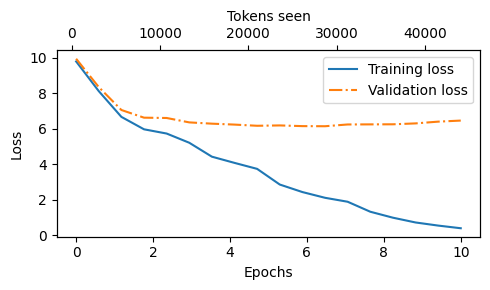

In [81]:
# Visualizing the loss trends

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))  # only show integer labels on x-axis

    # Create a second x-axis for tokens seen
    ax2 = ax1.twiny()  # Create a second x-axis that shares the same y-axis
    ax2.plot(tokens_seen, train_losses, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Tokens seen")

    fig.tight_layout()  # Adjust layout to make room
    plt.savefig("loss-plot.pdf")
    plt.show()

epochs_tensor = torch.linspace(0, 10, len(traininglosses))
plot_losses(epochs_tensor, tokensseen, traininglosses, validationlosses)

In [82]:
# We'll use Multinomial method to choose the likely token to be generated since argmax is not finding optimal solution

def generate(model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=None):

    # For-loop is the same as before: Get logits, and only focus on last time step
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]

        # New: Filter logits with top_k sampling
        if top_k is not None:
            # Keep only top_k values
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1]
            logits = torch.where(logits < min_val, torch.tensor(float("-inf")).to(logits.device), logits)

        # New: Apply temperature scaling
        if temperature > 0.0:
            logits = logits / temperature

            # New (not in book): numerical stability tip to get equivalent results on mps device
            # subtract rowwise max before softmax
            logits = logits - logits.max(dim=-1, keepdim=True).values

            # Apply softmax to get probabilities
            probs = torch.softmax(logits, dim=-1)  # (batch_size, context_len)

            # Sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1)  # (batch_size, 1)

        # Otherwise same as before: get idx of the vocab entry with the highest logits value
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)  # (batch_size, 1)

        if idx_next == eos_id:  # Stop generating early if end-of-sequence token is encountered and eos_id is specified
            break

        # Same as before: append sampled index to the running sequence
        idx = torch.cat((idx, idx_next), dim=1)  # (batch_size, num_tokens+1)

    return idx

In [83]:
torch.manual_seed(123)

token_ids = generate(
    model=model,
    idx=texttotokenids("Every day moves", tokenizer).to(device),
    max_new_tokens=15,
    context_size=Configuration_for_GPT_Model_124MParamsUpdated["contextlength"],
    top_k=25,
    temperature=1
)

print("Output text:\n", tokenidstotext(token_ids, tokenizer))

token ids 1: tensor([[ 6109,  1110,  6100, 40642,   972,  6654,   832,   616,  5975,    11,
           345,   760,    11,   262, 47914,  1298,   319,   326]])
Output text:
 Every day moves amazement escape through my surprise, you know, theinteresting": on that


In [84]:
torch.save(model.state_dict(), "model.pth")

In [85]:
model = GPTModel(Configuration_for_GPT_Model_124MParamsUpdated)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    # Use PyTorch 2.9 or newer for stable mps results
    major, minor = map(int, torch.__version__.split(".")[:2])
    if (major, minor) >= (2, 9):
        device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Device:", device)

model.load_state_dict(torch.load("model.pth", map_location=device, weights_only=True))
model.eval();

{'vocabularysize': 50257, 'contextlength': 256, 'embeddingdimension': 768, 'numberofheads': 12, 'numberoflayers': 12, 'dropoutrate': 0.1, 'qkvbias': False}
Device: cpu


In [86]:
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    },
    "model_and_optimizer.pth"
)

In [87]:
checkpoint = torch.load("model_and_optimizer.pth", weights_only=True)

model = GPTModel(Configuration_for_GPT_Model_124MParamsUpdated)
model.load_state_dict(checkpoint["model_state_dict"])

optimizer = torch.optim.AdamW(model.parameters(), lr=0.0005, weight_decay=0.1)
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
model.train();

{'vocabularysize': 50257, 'contextlength': 256, 'embeddingdimension': 768, 'numberofheads': 12, 'numberoflayers': 12, 'dropoutrate': 0.1, 'qkvbias': False}


In [88]:
pip install tensorflow tqdm

In [89]:
import requests
import json
import numpy as np
import tensorflow as tf
from tqdm import tqdm
def download_and_load_gpt2(model_size, models_dir):
    # Validate model size
    allowed_sizes = ("124M", "355M", "774M", "1558M")
    if model_size not in allowed_sizes:
        raise ValueError(f"Model size not in {allowed_sizes}")

    # Define paths
    model_dir = os.path.join(models_dir, model_size)
    base_url = "https://openaipublic.blob.core.windows.net/gpt-2/models"
    backup_base_url = "https://f001.backblazeb2.com/file/LLMs-from-scratch/gpt2"
    filenames = [
        "checkpoint", "encoder.json", "hparams.json",
        "model.ckpt.data-00000-of-00001", "model.ckpt.index",
        "model.ckpt.meta", "vocab.bpe"
    ]

    # Download files
    os.makedirs(model_dir, exist_ok=True)
    for filename in filenames:
        file_url = os.path.join(base_url, model_size, filename)
        backup_url = os.path.join(backup_base_url, model_size, filename)
        file_path = os.path.join(model_dir, filename)
        download_file(file_url, file_path, backup_url)

    # Load settings and params
    tf_ckpt_path = tf.train.latest_checkpoint(model_dir)
    settings = json.load(open(os.path.join(model_dir, "hparams.json"), "r", encoding="utf-8"))
    params = load_gpt2_params_from_tf_ckpt(tf_ckpt_path, settings)

    return settings, params


In [90]:
def download_file(url, destination, backup_url=None):
    def _attempt_download(download_url):
        response = requests.get(download_url, stream=True, timeout=60)
        response.raise_for_status()

        file_size = int(response.headers.get("Content-Length", 0))

        # Check if file exists and has same size
        if os.path.exists(destination):
            file_size_local = os.path.getsize(destination)
            if file_size and file_size == file_size_local:
                print(f"File already exists and is up-to-date: {destination}")
                return True

        block_size = 1024  # 1 KB
        desc = os.path.basename(download_url)
        with tqdm(total=file_size, unit="iB", unit_scale=True, desc=desc) as progress_bar:
            with open(destination, "wb") as file:
                for chunk in response.iter_content(chunk_size=block_size):
                    if chunk:
                        file.write(chunk)
                        progress_bar.update(len(chunk))
        return True

    try:
        if _attempt_download(url):
            return
    except requests.exceptions.RequestException:
        if backup_url is not None:
            print(f"Primary URL ({url}) failed. Attempting backup URL: {backup_url}")
            try:
                if _attempt_download(backup_url):
                    return
            except requests.exceptions.RequestException:
                pass

        error_message = (
            f"Failed to download from both primary URL ({url})"
            f"{' and backup URL (' + backup_url + ')' if backup_url else ''}."
            "\nCheck your internet connection or the file availability.\n"
            "For help, visit: https://github.com/rasbt/LLMs-from-scratch/discussions/273"
        )
        print(error_message)
    except Exception as e:
        print(f"An unexpected error occurred: {e}")

In [91]:

def load_gpt2_params_from_tf_ckpt(ckpt_path, settings):
    # Initialize parameters dictionary with empty blocks for each layer
    params = {"blocks": [{} for _ in range(settings["n_layer"])]}

    # Iterate over each variable in the checkpoint
    for name, _ in tf.train.list_variables(ckpt_path):
        # Load the variable and remove singleton dimensions
        variable_array = np.squeeze(tf.train.load_variable(ckpt_path, name))

        # Process the variable name to extract relevant parts
        variable_name_parts = name.split("/")[1:]  # Skip the 'model/' prefix

        # Identify the target dictionary for the variable
        target_dict = params
        if variable_name_parts[0].startswith("h"):
            layer_number = int(variable_name_parts[0][1:])
            target_dict = params["blocks"][layer_number]

        # Recursively access or create nested dictionaries
        for key in variable_name_parts[1:-1]:
            target_dict = target_dict.setdefault(key, {})

        # Assign the variable array to the last key
        last_key = variable_name_parts[-1]
        target_dict[last_key] = variable_array

    return params

In [92]:
settings, params = download_and_load_gpt2(model_size="124M", models_dir="gpt2")

checkpoint: 100%|██████████| 77.0/77.0 [00:00<00:00, 47.5kiB/s]
encoder.json: 100%|██████████| 1.04M/1.04M [00:00<00:00, 4.78MiB/s]
hparams.json: 100%|██████████| 90.0/90.0 [00:00<00:00, 108kiB/s]
model.ckpt.data-00000-of-00001: 100%|██████████| 498M/498M [00:25<00:00, 19.4MiB/s]
model.ckpt.index: 100%|██████████| 5.21k/5.21k [00:00<00:00, 10.2MiB/s]
model.ckpt.meta: 100%|██████████| 471k/471k [00:00<00:00, 3.19MiB/s]
vocab.bpe: 100%|██████████| 456k/456k [00:00<00:00, 2.70MiB/s]


In [93]:
print("Settings:", settings)

Settings: {'n_vocab': 50257, 'n_ctx': 1024, 'n_embd': 768, 'n_head': 12, 'n_layer': 12}


In [94]:
print("Parameter dictionary keys:", params.keys())

Parameter dictionary keys: dict_keys(['blocks', 'b', 'g', 'wpe', 'wte'])


In [95]:
print(params["wte"])
print("Token embedding weight tensor dimensions:", params["wte"].shape)

[[-0.11010301 -0.03926672  0.03310751 ... -0.1363697   0.01506208
   0.04531523]
 [ 0.04034033 -0.04861503  0.04624869 ...  0.08605453  0.00253983
   0.04318958]
 [-0.12746179  0.04793796  0.18410145 ...  0.08991534 -0.12972379
  -0.08785918]
 ...
 [-0.04453601 -0.05483596  0.01225674 ...  0.10435229  0.09783269
  -0.06952604]
 [ 0.1860082   0.01665728  0.04611587 ... -0.09625227  0.07847701
  -0.02245961]
 [ 0.05135201 -0.02768905  0.0499369  ...  0.00704835  0.15519823
   0.12067825]]
Token embedding weight tensor dimensions: (50257, 768)


In [96]:
model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

# Copy the base configuration and update with specific model settings
model_name = "gpt2-small (124M)"  # Example model name
NEW_CONFIG = Configuration_for_GPT_Model_124MParamsUpdated.copy()
NEW_CONFIG.update(model_configs[model_name])
NEW_CONFIG.update({"contextlength": 1024, "qkvbias": True})

gpt = GPTModel(NEW_CONFIG)
gpt.eval();

{'vocabularysize': 50257, 'contextlength': 1024, 'embeddingdimension': 768, 'numberofheads': 12, 'numberoflayers': 12, 'dropoutrate': 0.1, 'qkvbias': True, 'emb_dim': 768, 'n_layers': 12, 'n_heads': 12}


In [97]:
def assign(left, right):
    if left.shape != right.shape:
        raise ValueError(f"Shape mismatch. Left: {left.shape}, Right: {right.shape}")
    return torch.nn.Parameter(torch.tensor(right))

In [98]:
import numpy as np

def load_weights_into_gpt(gpt, params):
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params['wpe'])
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params['wte'])

    for b in range(len(params["blocks"])):
        q_w, k_w, v_w = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1)
        gpt.trf_blocks[b].attentionlayer.Wquery.weight = assign(
            gpt.trf_blocks[b].attentionlayer.Wquery.weight, q_w.T)
        gpt.trf_blocks[b].attentionlayer.Wkey.weight = assign(
            gpt.trf_blocks[b].attentionlayer.Wkey.weight, k_w.T)
        gpt.trf_blocks[b].attentionlayer.Wvalue.weight = assign(
            gpt.trf_blocks[b].attentionlayer.Wvalue.weight, v_w.T)

        q_b, k_b, v_b = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)
        gpt.trf_blocks[b].attentionlayer.Wquery.bias = assign(
            gpt.trf_blocks[b].attentionlayer.Wquery.bias, q_b)
        gpt.trf_blocks[b].attentionlayer.Wkey.bias = assign(
            gpt.trf_blocks[b].attentionlayer.Wkey.bias, k_b)
        gpt.trf_blocks[b].attentionlayer.Wvalue.bias = assign(
            gpt.trf_blocks[b].attentionlayer.Wvalue.bias, v_b)

        gpt.trf_blocks[b].attentionlayer.opproj.weight = assign(
            gpt.trf_blocks[b].attentionlayer.opproj.weight,
            params["blocks"][b]["attn"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].attentionlayer.opproj.bias = assign(
            gpt.trf_blocks[b].attentionlayer.opproj.bias,
            params["blocks"][b]["attn"]["c_proj"]["b"])

        gpt.trf_blocks[b].feedforwardlayer.layers[0].weight = assign(
            gpt.trf_blocks[b].feedforwardlayer.layers[0].weight,
            params["blocks"][b]["mlp"]["c_fc"]["w"].T)
        gpt.trf_blocks[b].feedforwardlayer.layers[0].bias = assign(
            gpt.trf_blocks[b].feedforwardlayer.layers[0].bias,
            params["blocks"][b]["mlp"]["c_fc"]["b"])
        gpt.trf_blocks[b].feedforwardlayer.layers[2].weight = assign(
            gpt.trf_blocks[b].feedforwardlayer.layers[2].weight,
            params["blocks"][b]["mlp"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].feedforwardlayer.layers[2].bias = assign(
            gpt.trf_blocks[b].feedforwardlayer.layers[2].bias,
            params["blocks"][b]["mlp"]["c_proj"]["b"])

        gpt.trf_blocks[b].normalizationlayer1.scale = assign(
            gpt.trf_blocks[b].normalizationlayer1.scale,
            params["blocks"][b]["ln_1"]["g"])
        gpt.trf_blocks[b].normalizationlayer1.shift = assign(
            gpt.trf_blocks[b].normalizationlayer1.shift,
            params["blocks"][b]["ln_1"]["b"])
        gpt.trf_blocks[b].normalizationlayer2.scale = assign(
            gpt.trf_blocks[b].normalizationlayer2.scale,
            params["blocks"][b]["ln_2"]["g"])
        gpt.trf_blocks[b].normalizationlayer2.shift = assign(
            gpt.trf_blocks[b].normalizationlayer2.shift,
            params["blocks"][b]["ln_2"]["b"])

    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])
    gpt.out_head.weight = assign(gpt.out_head.weight, params["wte"])


load_weights_into_gpt(gpt, params)
gpt.to(device);

In [101]:
#torch.manual_seed(123)

# Text Completion
token_ids = generate(
    model=gpt,
    idx=texttotokenids("Are you very", tokenizer).to(device),
    max_new_tokens=50,
    context_size=NEW_CONFIG["contextlength"],
    top_k=50,
    temperature=1.5
)

print("Output text:\n", tokenidstotext(token_ids, tokenizer))

token ids 1: tensor([[ 8491,   345,   845,  2726,  8348,  1320,   338,   340,    13,  1375,
          1392,   510,    11,   523,   314,  2067,  6155,   355,   340,  4325,
           553,  1139,   257,  2368,   582,    11,   783, 12049,   287,   257,
          2266, 10147,   508,  2925,   416,  4502,   329,  6439,  3840,    13,
           775,  2513,  3812,   360,  1789, 38599,   338,  7962,    11,   290,
           788,   766,   360]])
Output text:
 Are you very serious?' That's it. She got up, so I started walking as it happens," says a third man, now dressed in a red shirt who goes by George for unknown reasons. We walk toward Diamonte's apartment, and then see D
